In [1]:
import pandas as pd

# Load raw data with latin-1 encoding to handle special characters
df = pd.read_csv(r"C:\Users\durel\Documents\Python Programming - Wfu\Personal Projects\novasend-fulfillment-risk\data\raw\DataCoSupplyChainDataset.csv", encoding="latin-1", low_memory=False)

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 180,519  |  Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
# Check how balanced our target variable is
print(df["Late_delivery_risk"].value_counts())
print()
print(df["Late_delivery_risk"].value_counts(normalize=True).round(3))

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


In [3]:
# Shows column names, non-null counts, and dtypes in one view
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [4]:
# Full list of columns to drop before any analysis or modeling
cols_to_drop = [
    # Leakage: recorded post-delivery
    "Days for shipping (real)",
    "Delivery Status",
    "Benefit per order",
    "Order Profit Per Order",

    # Peronsal Identifiers: no predictive value
    "Customer Email",
    "Customer Fname",
    "Customer Lname",
    "Customer Password",

    # ID columns: no predictive signal
    "Customer Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",

    # Redundant IDs where name column already exists
    "Category Id",
    "Department Id",
    "Product Category Id",

    # Empty or non-tabular
    "Product Description",
    "Product Image",

    # Store location: Order Region and Market cover destination geography better
    "Latitude",
    "Longitude",

    # Too sparse or granular to model reliably
    "Customer Street",
    "Customer Zipcode",
    "Order Zipcode",
]

# Drop all at once and confirm what we have left
df_clean = df.drop(columns=cols_to_drop)

print(f"Columns remaining: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns remaining: 29
['Type', 'Days for shipment (scheduled)', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [5]:
# Drop profit ratio and shipping date: not available at order intake
df_clean = df_clean.drop(columns=["Order Item Profit Ratio", "shipping date (DateOrders)"])

print(f"Columns remaining: {df_clean.shape[1]}")

Columns remaining: 27


In [6]:
# Check null counts and percentage across all remaining columns
null_summary = pd.DataFrame({
    "null_count": df_clean.isnull().sum(),
    "null_pct": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

# Only show columns that actually have nulls
print(null_summary[null_summary["null_count"] > 0])

Empty DataFrame
Columns: [null_count, null_pct]
Index: []


### Target Distribution

First thing I want to see is how balanced the target variable is.
This drives the entire imbalance strategy for modeling

Turns out it's roughly 55/45 which is close enough to balanced that I don't need any class weighting
That simplifies the modeling phase significantly.

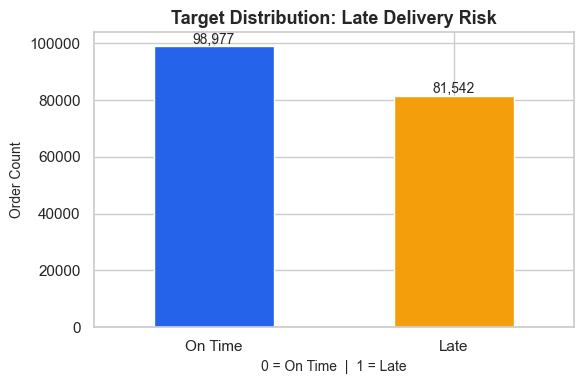

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean consistent style for all EDA plots
sns.set_theme(style="whitegrid", palette="muted")

# Target distribution
fig, ax = plt.subplots(figsize=(6, 4))

df_clean["Late_delivery_risk"].value_counts().plot(
    kind="bar",
    ax=ax,
    color=["#2563EB", "#F59E0B"],  # blue for on-time, amber for late
    edgecolor="white"
)

ax.set_title("Target Distribution: Late Delivery Risk", fontsize=13, fontweight="bold")
ax.set_xlabel("0 = On Time  |  1 = Late", fontsize=10)
ax.set_ylabel("Order Count", fontsize=10)
ax.set_xticklabels(["On Time", "Late"], rotation=0)

# Annotate bars with counts
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()

import os

# Walk up one level from notebooks/ to reach the repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Build the full path to reports/figures
figures_dir = os.path.join(repo_root, "reports", "figures")
os.makedirs(figures_dir, exist_ok=True)

# Save using the full path
fig.savefig(os.path.join(figures_dir, "01_target_distribution.png"), dpi=150, bbox_inches="tight")

plt.show()

### Late Delivery Rate by Shipping Mode

Shipping mode is one of the strongest candidates for predicting late delivery.
Same Day and First Class should theoretically have lower late rates.

C:\Users\durel\AppData\Local\Temp\ipykernel_14020\3521426733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


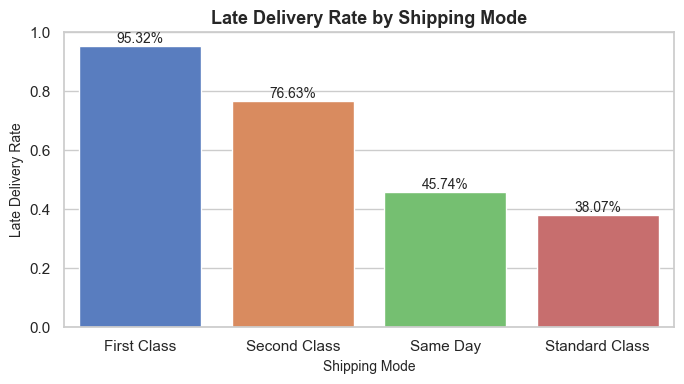

In [8]:
# Calculate late delivery rate by shipping mode
shipping_risk = (
    df_clean.groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=shipping_risk,
    x="Shipping Mode",
    y="Late_delivery_risk",
    palette="muted",
    ax=ax
)

ax.set_title("Late Delivery Rate by Shipping Mode", fontsize=13, fontweight="bold")
ax.set_xlabel("Shipping Mode", fontsize=10)
ax.set_ylabel("Late Delivery Rate", fontsize=10)
ax.set_ylim(0, 1)

# Annotate each bar with the exact rate
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

fig.savefig(os.path.join(figures_dir, "02_late_rate_by_shipping_mode.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

This was the most surprising result in the EDA. First Class has a 95% late delivery rate, the highest of any shipping mode, which is the opposite of what you'd expect from a premium tier.
Standard Class at 38% is actually the most reliable mode in the dataset.
This suggests the late delivery risk isn't just about speed expectations, it likely reflects how NovaSend allocates resources across shipping tiers.
Shipping Mode will almost certainly be one of the top features in the final model.

### Late Delivery Rate by Market

Market tells us where the order is being delivered geographically.
I'd expect regions with longer shipping distances or weaker logistics infrastructure to show higher late rates.

C:\Users\durel\AppData\Local\Temp\ipykernel_14020\2415816415.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


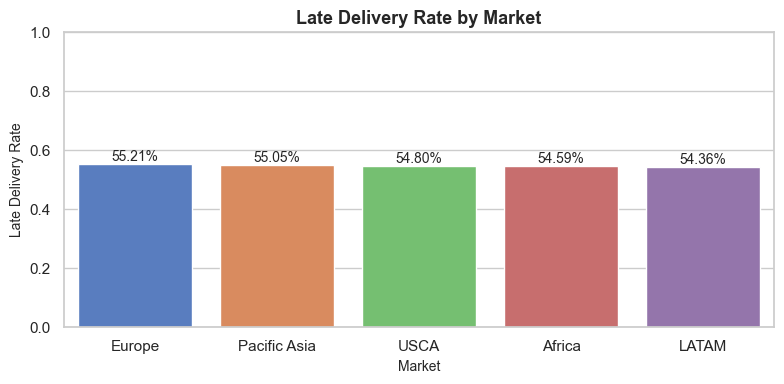

In [9]:
# Calculate late delivery rate by market
market_risk = (
    df_clean.groupby("Market")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=market_risk,
    x="Market",
    y="Late_delivery_risk",
    palette="muted",
    ax=ax
)

ax.set_title("Late Delivery Rate by Market", fontsize=13, fontweight="bold")
ax.set_xlabel("Market", fontsize=10)
ax.set_ylabel("Late Delivery Rate", fontsize=10)
ax.set_ylim(0, 1)

# Annotate each bar with the exact rate
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

fig.savefig(os.path.join(figures_dir, "03_late_rate_by_market.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

Every market lands between 54% and 55% late delivery rate, essentially identical across all five regions.
This is worth noting because it's counterintuitive. You'd expect geography to matter for fulfillment risk.

The likely explanation is that late delivery in this dataset is driven by internal operational factors
like shipping mode and order complexity, not by where the order is going.
Market will likely rank near the bottom of feature importance in the final model.

### Late Delivery Rate by Order Status

Order Status captures where an order is in the fulfillment lifecycle at the time of recording.
Some statuses like SUSPECTED_FRAUD or ON_HOLD may have very different late delivery profiles than COMPLETE orders.
This could be strong signal or it could reflect post-intake information we need to be careful about.

C:\Users\durel\AppData\Local\Temp\ipykernel_14020\2859569328.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\durel\AppData\Local\Temp\ipykernel_14020\2859569328.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


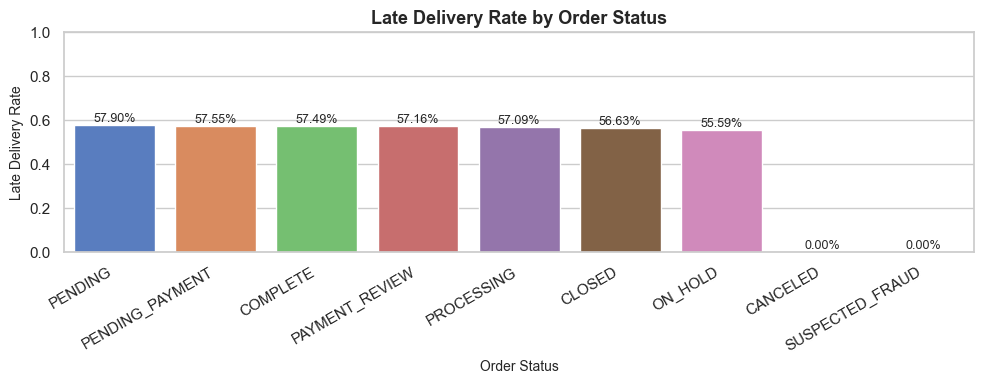

In [10]:
# Calculate late delivery rate by order status
status_risk = (
    df_clean.groupby("Order Status")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    data=status_risk,
    x="Order Status",
    y="Late_delivery_risk",
    palette="muted",
    ax=ax
)

ax.set_title("Late Delivery Rate by Order Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Order Status", fontsize=10)
ax.set_ylabel("Late Delivery Rate", fontsize=10)
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

# Annotate each bar with the exact rate
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

fig.savefig(os.path.join(figures_dir, "04_late_rate_by_order_status.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

Seven of nine order statuses cluster between 55% and 58%, essentially identical to the global late rate.
CANCELED and SUSPECTED_FRAUD show 0% but that's a structural artifact — orders that never ship cannot be late.

This feature will likely add noise rather than signal in the model.
It may still get included in the pipeline but I'd expect it to rank near the bottom of feature importance
alongside Market.

### Numeric Feature Distributions

Now I want to look at the distribution of the numeric features remaining in the dataset.
The goal here is to catch skewness, outliers, and anything that might need transformation before modeling.

In [11]:
# Select numeric columns excluding the target variable
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Late_delivery_risk"]

print(f"Numeric features to plot: {numeric_cols}")

Numeric features to plot: ['Days for shipment (scheduled)', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Product Price', 'Product Status']


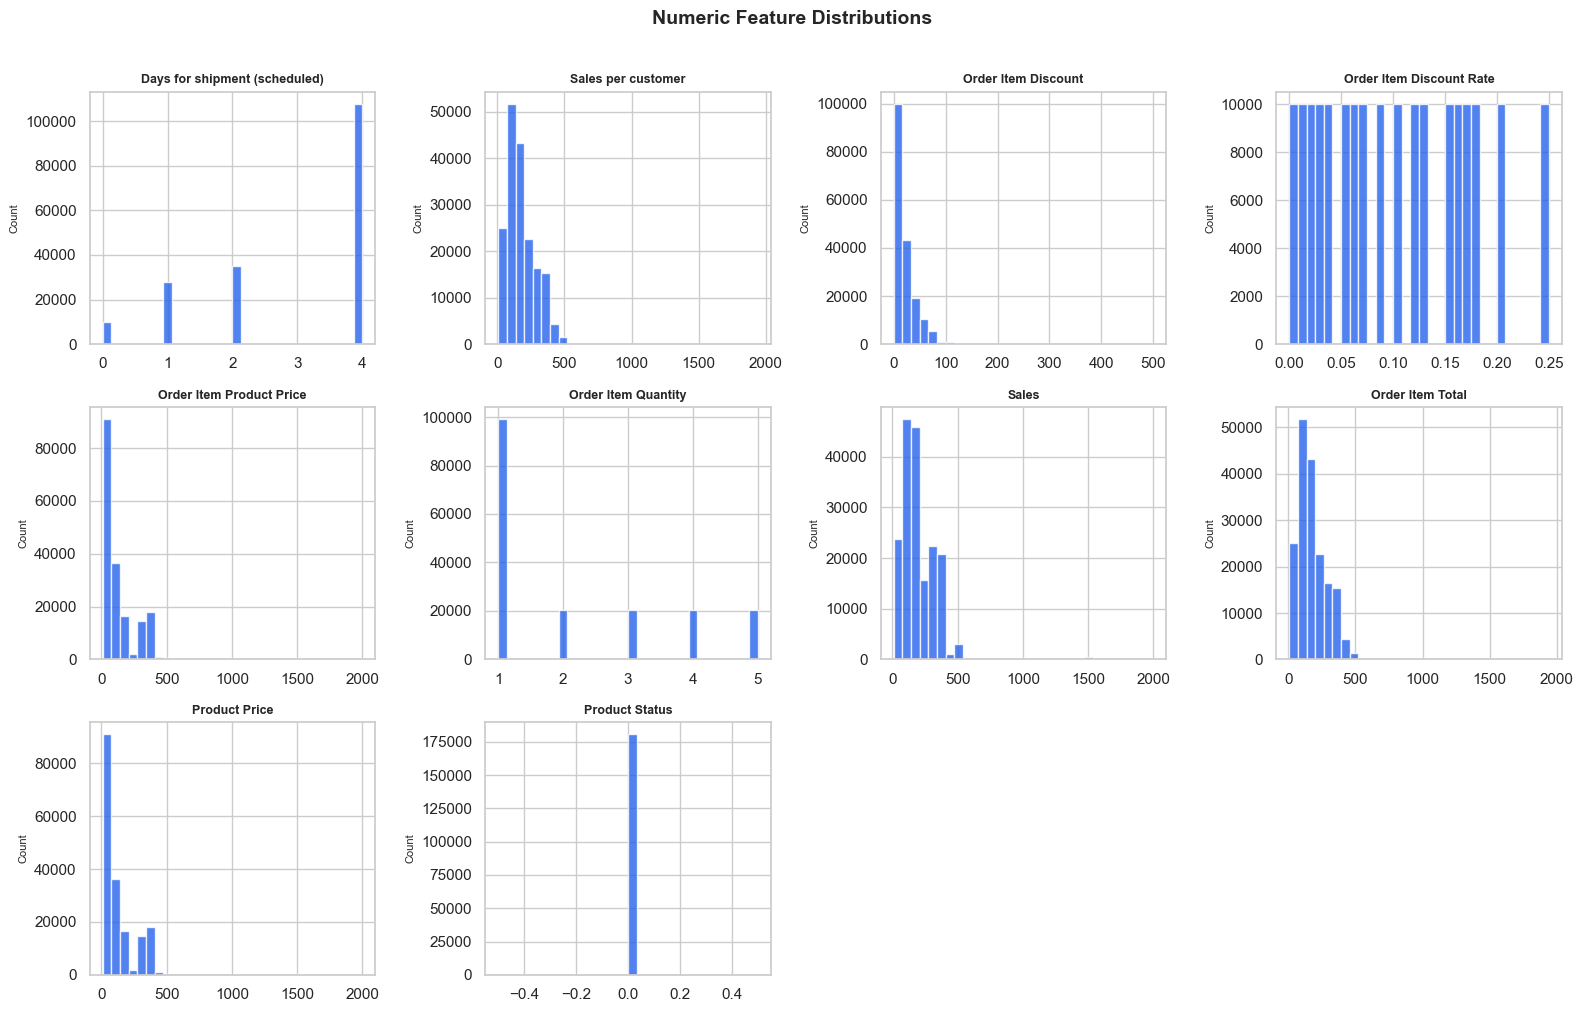

In [12]:
# Plot distributions for all numeric features in a grid
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(
        df_clean[col],
        bins=30,
        color="#2563EB",
        edgecolor="white",
        alpha=0.8
    )
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize=8)

# Hide the two unused subplot slots in the grid
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.01)

fig.savefig(os.path.join(figures_dir, "05_numeric_distributions.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [13]:
# Investigate unexpected values in Product Status
print(df_clean["Product Status"].value_counts())
print()
print(f"Min: {df_clean['Product Status'].min()}")
print(f"Max: {df_clean['Product Status'].max()}")

Product Status
0    180519
Name: count, dtype: int64

Min: 0
Max: 0


In [14]:
# Product Status has no variance, so I'm dropping the column.
df_clean = df_clean.drop(columns=["Product Status"])

print(f"Columns remaining: {df_clean.shape[1]}")

Columns remaining: 26


Several price and sales columns are heavily right skewed including Sales, Order Item Total,
Product Price, Order Item Product Price and Sales per customer. I'll use log transformation
before modeling to prevent the model from being dominated by extreme values.

Order Item Discount Rate shows a uniform distribution across discrete tiers which is intentional
based on how discounts are structured in this dataset.

Product Status was dropped entirely. Every record has a value of 0 meaning every product
is marked as in stock. A feature with zero variance adds nothing to a model.

Days for shipment (scheduled) and Order Item Quantity are clean and ready to use as is.

### Correlation Analysis

Now I want to see how the numeric features correlate with the target variable and with each other.
High correlation between features can cause multicollinearity issues in some models.
More importantly I want to see which numeric features have the strongest relationship with Late_delivery_risk.

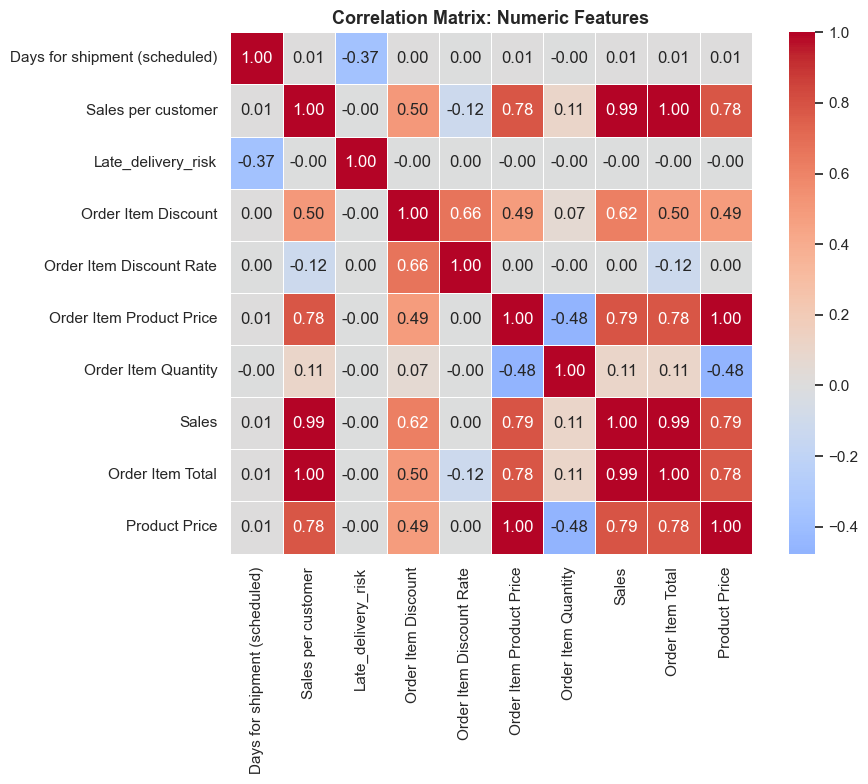

In [15]:
# Compute correlation matrix across all remaining numeric features including target
corr_matrix = df_clean.select_dtypes(include=["int64", "float64"]).corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,              # show correlation values in each cell
    fmt=".2f",               # round to 2 decimal places
    cmap="coolwarm",         # red for positive, blue for negative correlation
    center=0,                # center the colormap at zero
    square=True,             # keep cells square
    linewidths=0.5,          # add gridlines between cells
    ax=ax
)

ax.set_title("Correlation Matrix: Numeric Features", fontsize=13, fontweight="bold")

fig.savefig(os.path.join(figures_dir, "06_correlation_matrix.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

Days for shipment (scheduled) is the only numeric feature with meaningful correlation
to the target at 0.37. Every other numeric feature is essentially uncorrelated with Late_delivery_risk.
This reinforces that the real predictive signal in this dataset is operational, not financial.

Several feature pairs show near perfect multicollinearity. Sales, Order Item Total and
Sales per customer are essentially the same signal. Order Item Product Price and Product Price
are identical. Keeping redundant features adds noise without adding information.

Sales, Order Item Total and Product Price will be dropped before modeling.

In [16]:
# Drop redundant features identified through correlation analysis
df_clean = df_clean.drop(columns=["Sales", "Order Item Total", "Product Price"])

print(f"Columns remaining: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns remaining: 23
['Type', 'Days for shipment (scheduled)', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Quantity', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


In [17]:
import os

# Build path to processed data folder anchored at repo root
processed_dir = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Save cleaned DataFrame as CSV — no index column needed
df_clean.to_csv(os.path.join(processed_dir, "data_clean.csv"), index=False)

print(f"Saved to: {os.path.join(processed_dir, 'data_clean.csv')}")
print(f"Shape: {df_clean.shape}")

Saved to: C:\Users\durel\Documents\Python Programming - Wfu\Personal Projects\novasend-fulfillment-risk\data\processed\data_clean.csv
Shape: (180519, 23)
